# "Шапка" с названием проекта

В этой ячейке вы найдете оглавление и ключевые этапы работы, которые помогут вам ориентироваться в процессе выполнения проекта. Проект разделен на пять основных этапов, четыре из которых (этапы 2, 3, 4 и 5) вам предлагается выполнить в этом Jupyter Notebook:

- Подготовка среды MLflow - Первый шаг, подготовка и запуск сервисов MLflow, был выполнен вне ноутбука и оформлен в виде shell скрипта. Это основа для работы с экспериментами и логирования результатов ваших моделей.

- Этап 2 - Исследовательский Анализ Данных (EDA): На этом этапе вы проведете тщательный анализ данных, чтобы лучше понять их структуру и особенности.

- Этап 3 - Генерация Признаков и Обучение Модели: После анализа данных вы сгенерируете новые признаки и обучите модель, используя эти признаки.

- Этап 4 - Отбор Признаков и Обучение Модели: На этом шаге вы отберете наиболее значимые признаки и снова обучите модель для улучшения ее качества.

- Этап 5 - Подбор Гиперпараметров и Обучение Финальной Версии Модели: Финальный этап проекта посвящен оптимизации гиперпараметров для достижения максимального качества модели.

Для удобства навигации и организации работы, пожалуйста, следуйте оглавлению и рекомендациям, описанным в каждом этапе.

> ## Важно: Переобучение моделей
> На каждом этапе проекта, где требуется переобучение модели, важно не просто выполнить эту процедуру, но и тщательно проверить качество модели на соответствующих выборках. Это включает в себя анализ метрик качества, визуализацию результатов, сравнение с предыдущими моделями и, при необходимости, корректировку.

> ## Важно: Разделение выборок
> Перед началом выполнения вашего проекта важно правильно подготовить данные, разделив их на подвыборки. Это позволит оценить производительность модели более объективно и управлять риском переобучения. В зависимости от ваших целей и доступных данных, вы можете использовать различные стратегии разделения:

1. Разделение на train/val/test: Это классический подход, где данные делятся на три части. Обучающая выборка (train) используется для первичного обучения моделей, валидационная (val) - для настройки гиперпараметров и выбора лучшей модели, а тестовая (test) - для финальной оценки производительности модели. Такой подход идеален, если у вас достаточно данных, чтобы разделить их и каждая из выборок была репрезентативна.

2. Разделение на train/test с кросс-валидацией на train: Если данных недостаточно для трех подвыборок, можно ограничиться разделением на обучающую и тестовую выборки. В этом случае кросс-валидация на обучающей выборке поможет оценить стабильность модели и подобрать гиперпараметры.

Определение способа разделения данных: Выбор метода разбиения данных на подвыборки — train, validation и test — должен быть обоснован особенностями вашего набора данных и задачами проекта. Возможные методы разделения, включая различные стратегии и правила, подробно описаны в [документации scikit-learn по разбиению данных](https://scikit-learn.org/stable/auto_examples/model_selection/plot_cv_indices.html#sphx-glr-auto-examples-model-selection-plot-cv-indices-py). Вы можете следовать этим примерам или разработать собственный метод, исходя из специфики ваших данных.

Ваша задача - выбрать подходящий метод разделения данных исходя из объема и специфики ваших данных. Помните, что финальные метрики качества модели мы будем оценивать на тестовой выборке. Промежуточные результаты после каждого этапа проекта (например, после настройки гиперпараметров) следует оценивать на валидационной выборке, если таковая имеется. Это поможет вам корректно настроить модель перед финальной оценкой её производительности.

## Импортируем библиотеки

In [52]:
import os
import sys
import time
import subprocess
from datetime import datetime
from pathlib import Path
import joblib
from sklearn.base import BaseEstimator, TransformerMixin
import optuna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import FunctionTransformer
import mlflow
from mlflow.models import infer_signature
from mlflow.tracking import MlflowClient

from sklearn.ensemble import HistGradientBoostingRegressor
from sqlalchemy import create_engine
from category_encoders import CatBoostEncoder
from sklearn.model_selection import train_test_split, KFold, cross_validate, PredefinedSplit, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures, KBinsDiscretizer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
from catboost import CatBoostRegressor
from autofeat import AutoFeatRegressor

from sklearn.inspection import permutation_importance

from mlxtend.feature_selection import SequentialFeatureSelector

In [2]:
import numpy as np, mlxtend
print("numpy:", np.__version__)
print("mlxtend:", mlxtend.__version__)

numpy: 1.26.4
mlxtend: 0.23.4


In [3]:


EXPERIMENT_NAME = "model_FE_matevosov"
TABLE_NAME = "public.real_estate_dataset_clean"
TARGET_COL = "price"

REGISTERED_MODEL_NAME = "real_estate_price_model"

RANDOM_STATE = 42
TEST_SIZE = 0.2
VAL_SIZE = 0.2  

NOTEBOOK_PATH = Path("model_improvement") / "model_improvement.ipynb"
ART_DIR = Path("artifacts")
ART_DIR.mkdir(exist_ok=True)

def require_env(name: str) -> str:
    val = os.getenv(name)
    if not val:
        raise RuntimeError(f"Environment variable {name} is required")
    return val

def get_db_uri() -> str:
    host = require_env("DB_DESTINATION_HOST")
    port = require_env("DB_DESTINATION_PORT")
    user = require_env("DB_DESTINATION_USER")
    password = require_env("DB_DESTINATION_PASSWORD")
    dbname = os.getenv("DB_DESTINATION_DBNAME") or require_env("DB_DESTINATION_NAME")
    return f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{dbname}"

def load_dataset() -> pd.DataFrame:
    engine = create_engine(get_db_uri())
    df = pd.read_sql(f"SELECT * FROM {TABLE_NAME}", engine)
    if TARGET_COL not in df.columns:
        raise RuntimeError(f"Target column {TARGET_COL} not found in {TABLE_NAME}")
    return df

def setup_mlflow():
    tracking_uri = os.getenv("MLFLOW_TRACKING_URI", "http://127.0.0.1:5000")
    mlflow.set_tracking_uri(tracking_uri)
    mlflow.set_experiment(EXPERIMENT_NAME)

def log_environment():
    try:
        freeze = subprocess.check_output([sys.executable, "-m", "pip", "freeze"], text=True)
    except Exception as e:
        freeze = f"pip freeze failed: {e}"
    mlflow.log_text(freeze, "environment/pip_freeze.txt")

setup_mlflow()

df = load_dataset()

y = df[TARGET_COL].to_numpy()
X = df.drop(columns=[TARGET_COL])
X = X[[c for c in X.columns if not X[c].isna().all()]]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=VAL_SIZE,
    random_state=RANDOM_STATE,
)




## Этап 2: Исследовательский Анализ Данных (EDA)
На этом этапе ваша задача - провести тщательный исследовательский анализ данных (EDA), чтобы глубже понять особенности и связи в предоставленном наборе данных. В процессе EDA вы должны обратить внимание на три ключевых аспекта, о которых мы говорили в теме 3 курса. Очень важно, чтобы все результаты вашего исследования, включая визуализации, статистический анализ и предварительные выводы, были аккуратно залогированы в MLflow.

Для более организованного исследования предлагаем следующие рекомендуемые шаги:
- Понимание данных: Первоначально ознакомьтесь с данными, изучите типы данных, проверьте наличие пропущенных значений.
- Визуализация данных: Используйте графики и диаграммы для визуализации распределений признаков и возможных взаимосвязей между ними.
- Статистический анализ: Примените статистические методы для изучения центральных тенденций, разброса и корреляций между признаками.
- Предварительные выводы: На основе проведённого анализа сформулируйте предварительные выводы о данных, которые помогут в дальнейшем этапе моделирования.

Помните, что EDA - это итеративный процесс, в котором вы можете возвращаться к предыдущим шагам для дополнительного анализа, если это будет необходимо. Все находки и выводы должны быть чётко зафиксированы и легко доступны для команды проекта.


### Общий обзор датасета

In [4]:
df.head(3)

,flat_id,building_id,floor,kitchen_area,living_area,rooms,is_apartment,studio,total_area,price,build_year,building_type_int,latitude,longitude,ceiling_height,flats_count,floors_total,has_elevator
0,0,6220,9,9.9,19.900000,1,False,False,35.099998,9500000,1965,6,55.717113,37.781120,2.64,84,12,True
1,2,17821,9,9.0,32.000000,2,False,False,56.000000,13500000,2000,4,55.740040,37.761742,2.70,80,10,True
2,3,18579,1,10.1,43.099998,3,False,False,76.000000,20000000,2002,4,55.672016,37.570877,2.64,771,17,True


### Типы данных

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119522 entries, 0 to 119521
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   flat_id            119522 non-null  int64  
 1   building_id        119522 non-null  int64  
 2   floor              119522 non-null  int64  
 3   kitchen_area       119522 non-null  float64
 4   living_area        119522 non-null  float64
 5   rooms              119522 non-null  int64  
 6   is_apartment       119522 non-null  bool   
 7   studio             119522 non-null  bool   
 8   total_area         119522 non-null  float64
 9   price              119522 non-null  int64  
 10  build_year         119522 non-null  int64  
 11  building_type_int  119522 non-null  int64  
 12  latitude           119522 non-null  float64
 13  longitude          119522 non-null  float64
 14  ceiling_height     119522 non-null  float64
 15  flats_count        119522 non-null  int64  
 16  fl

### Статистики признаков

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
flat_id,119522.0,NaN,NaN,NaN,72221.814059,41127.096888,0.0,35647.25,73998.5,107350.75,141361.0
building_id,119522.0,NaN,NaN,NaN,13741.100768,6858.762476,1.0,8400.25,13890.0,19858.0,24620.0
floor,119522.0,NaN,NaN,NaN,7.328709,5.45439,1.0,3.0,6.0,10.0,56.0
kitchen_area,119522.0,NaN,NaN,NaN,9.29683,2.895663,1.75,7.0,9.0,10.5,15.75
living_area,119522.0,NaN,NaN,NaN,34.121134,15.379146,2.0,20.4,30.9,43.5,78.150001
rooms,119522.0,NaN,NaN,NaN,2.090393,0.950782,1.0,1.0,2.0,3.0,17.0
is_apartment,119522,2,False,118584,NaN,NaN,NaN,NaN,NaN,NaN,NaN
studio,119522,1,False,119522,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_area,119522.0,NaN,NaN,NaN,57.02666,21.870562,11.5,39.0,52.0,68.900002,113.750004
price,119522.0,NaN,NaN,NaN,13435399.163049,6196669.146686,11.0,8890000.0,11600000.0,16200000.0,27165000.0


Датасет содержит 119522 строк и 18 признаков, пропусков нет, типы данных представлены int64, float64 и bool.

### Сводка по категориальным и булевым

In [7]:

df.describe(include=["object", "category", "bool"]).T.head(30)


,count,unique,top,freq
is_apartment,119522,2,False,118584
studio,119522,1,False,119522
has_elevator,119522,2,True,107224


### Анализ признаков для модели

In [8]:
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
bool_cols = X.select_dtypes(include=["bool"]).columns.tolist()

forced_cat = ["building_type_int"]
for c in forced_cat:
    if c in num_cols:
        num_cols.remove(c)
    if c not in cat_cols:
        cat_cols.append(c)

# Эвристика по id-полям
id_like_cols = [c for c in X.columns if c.lower() == "id" or c.lower().endswith("_id")]

len(num_cols), len(cat_cols), len(bool_cols), id_like_cols[:10]



(13, 1, 3, ['flat_id', 'building_id'])

В этой ячейке выделяются списки числовых, категориальных и булевых признаков, а также автоматически находится набор id-похожих колонок для последующего исключения из моделирования. Так же нужно чтобы building_type_int попадала в категориальные переменные.

In [9]:
X['studio'].value_counts()

studio
False    119522
Name: count, dtype: int64

Все значения studio равны 0. Переменная константна. Можно избавиться потом.

Проверка пропусков

In [10]:

miss_cnt = X.isna().sum()
miss_pct = (miss_cnt / len(X) * 100).round(4)

missing_df = (
    pd.DataFrame({"missing_cnt": miss_cnt, "missing_pct": miss_pct})
    .sort_values("missing_pct", ascending=False)
)

missing_df.head()


,missing_cnt,missing_pct
flat_id,0,0.0
building_id,0,0.0
floor,0,0.0
kitchen_area,0,0.0
living_area,0,0.0


Проверка дубликатов строк целиком

In [11]:

dup_rows = df.duplicated().sum()
dup_rows


0

Сохраним отчет о пропусках

In [12]:

eda_dir = ART_DIR / "eda"
eda_dir.mkdir(parents=True, exist_ok=True)

miss_cnt = X.isna().sum()
miss_total = int(miss_cnt.sum())

miss_pct = (miss_cnt / len(X) * 100).round(4)

missing_df = (
    pd.DataFrame({"missing_cnt": miss_cnt, "missing_pct": miss_pct})
    .sort_values(["missing_cnt", "missing_pct"], ascending=False)
)

if miss_total == 0:
    print("Пропусков в признаках нет: missing_cnt=0 для всех колонок.")
    # Для проверяемости все равно покажем небольшой фрагмент таблицы
    missing_df.head(10)
    p_missing = None
else:
    # Показываем только колонки, где пропуски реально есть
    missing_nonzero = missing_df[missing_df["missing_cnt"] > 0].copy()

    n_show = min(30, len(missing_nonzero))
    display_df = missing_nonzero.head(n_show)

    print(f"Найдены пропуски: всего {miss_total} значений. Показаны топ-{n_show} колонок по числу пропусков.")
    display_df

    plt.figure(figsize=(10, 6))
    sns.barplot(x=display_df["missing_pct"].values, y=display_df.index)
    plt.title(f"Доля пропусков по признакам, топ-{n_show}")
    plt.xlabel("Пропуски, %")
    p_missing = eda_dir / "missingness_top.png"
    plt.savefig(p_missing, dpi=150, bbox_inches="tight")
    # plt.close()

p_missing


Пропусков в признаках нет: missing_cnt=0 для всех колонок.


### Анализ целевой переменной

(PosixPath('artifacts/eda/target_hist_kde.png'),
 PosixPath('artifacts/eda/target_boxplot.png'),
 PosixPath('artifacts/eda/target_qqplot.png'))

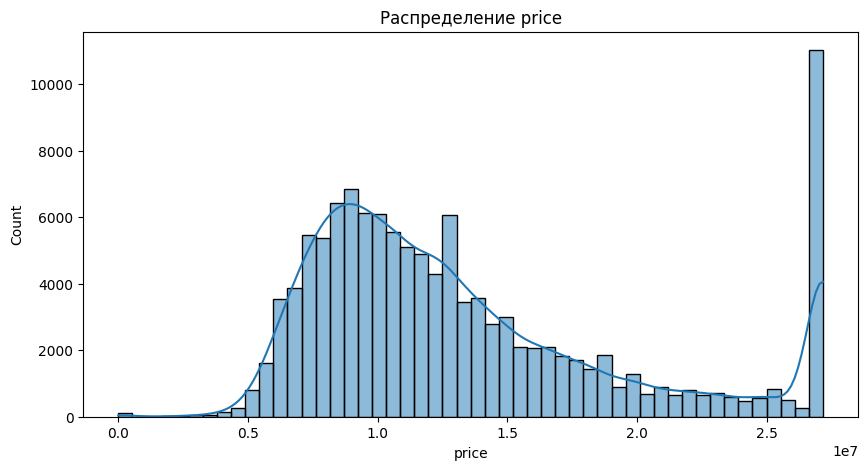

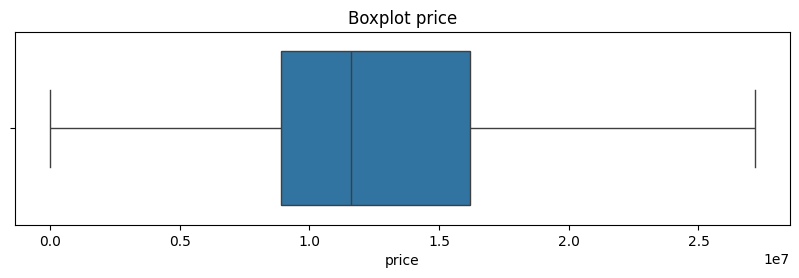

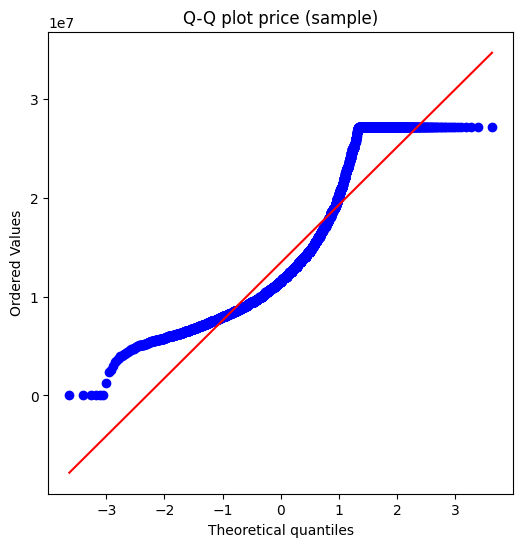

In [13]:
target = df[TARGET_COL].dropna()

# Распределение
plt.figure(figsize=(10, 5))
sns.histplot(target, bins=50, kde=True)
plt.title(f"Распределение {TARGET_COL}")
p_target_hist = eda_dir / "target_hist_kde.png"
plt.savefig(p_target_hist, dpi=150, bbox_inches="tight")
# plt.close()

# Boxplot
plt.figure(figsize=(10, 2.5))
sns.boxplot(x=target)
plt.title(f"Boxplot {TARGET_COL}")
p_target_box = eda_dir / "target_boxplot.png"
plt.savefig(p_target_box, dpi=150, bbox_inches="tight")
# plt.close()

# Q-Q plot (на подвыборке, чтобы не перегружать)
qq_sample = target.sample(n=min(len(target), 5000), random_state=RANDOM_STATE)
plt.figure(figsize=(6, 6))
stats.probplot(qq_sample, dist="norm", plot=plt)
plt.title(f"Q-Q plot {TARGET_COL} (sample)")
p_target_qq = eda_dir / "target_qqplot.png"
plt.savefig(p_target_qq, dpi=150, bbox_inches="tight")
# plt.close()

p_target_hist, p_target_box, p_target_qq


Числовые характеристики таргета для вывода

In [14]:
q01, q50, q99 = np.quantile(target, [0.01, 0.5, 0.99])
skew = float(target.skew())

target_summary = {
    "q01": float(q01),
    "median": float(q50),
    "q99": float(q99),
    "skew": float(skew),
}
target_summary


{'q01': 5300000.0,
 'median': 11600000.0,
 'q99': 27165000.0,
 'skew': 1.0041829201715486}

### Анализ целевой переменной в зависимости от различных признаков

,pearson,spearman,abs_pearson
total_area,0.791287,0.748188,0.791287
living_area,0.739320,0.696032,0.739320
rooms,0.627752,0.637443,0.627752
kitchen_area,0.552719,0.471499,0.552719
ceiling_height,0.518251,0.453683,0.518251
floors_total,0.244026,0.192669,0.244026
floor,0.171996,0.137518,0.171996
building_id,0.144270,0.160057,0.144270
build_year,0.130731,0.162107,0.130731
longitude,-0.117981,-0.149365,0.117981


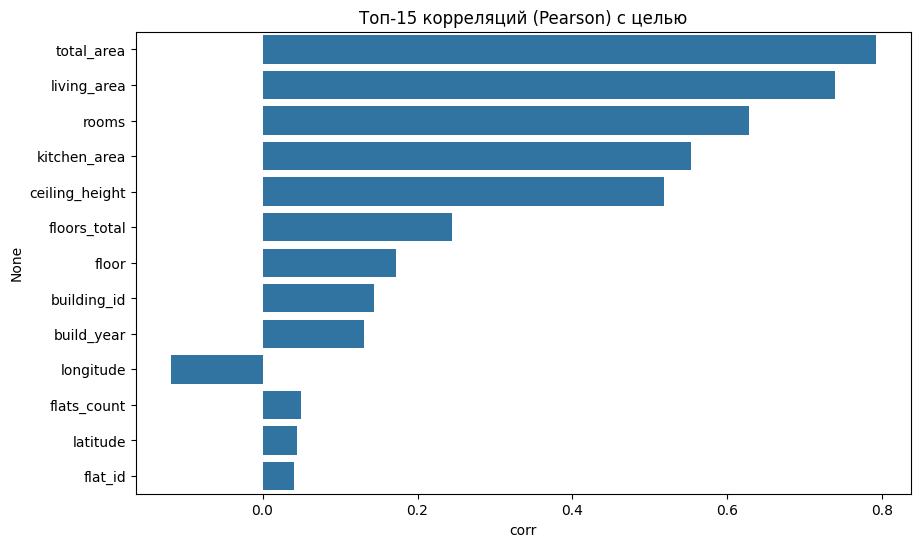

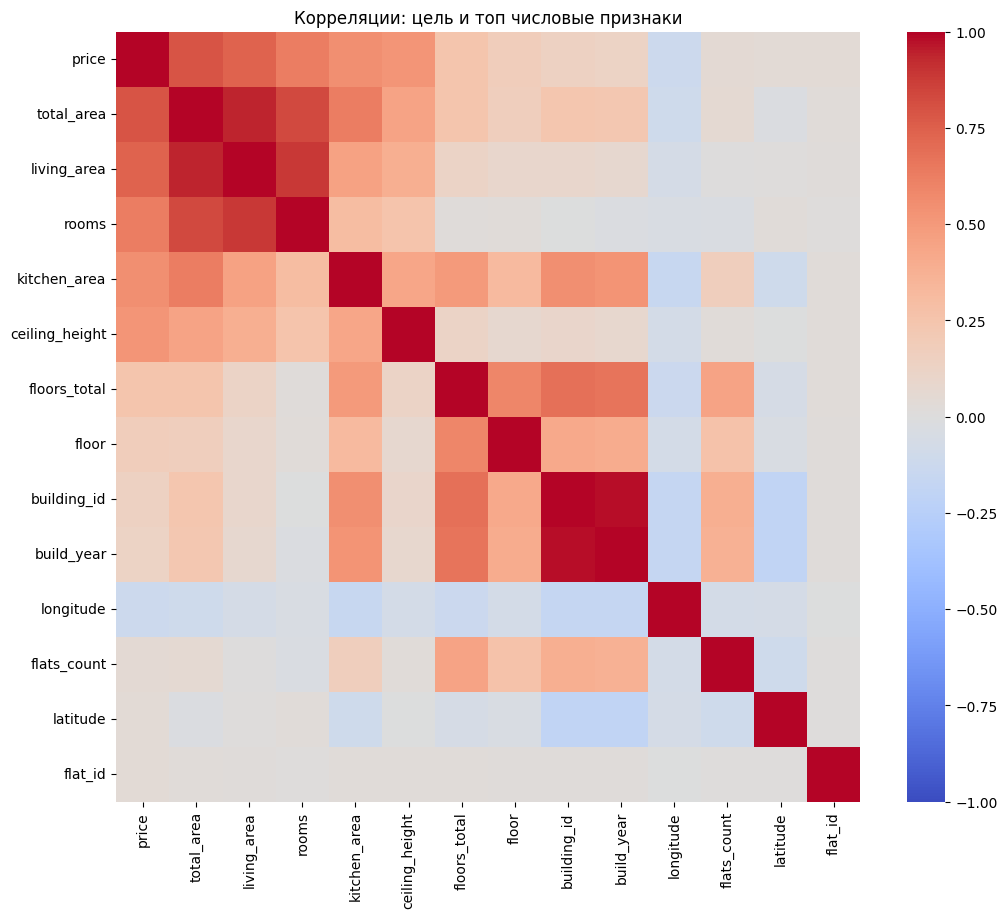

In [15]:
p_corr_heatmap = None
p_corr_bar = None

if len(num_cols) > 0:
    tmp = pd.DataFrame(X[num_cols]).copy()
    tmp[TARGET_COL] = df[TARGET_COL].to_numpy()

    corr_pearson = tmp.corr(numeric_only=True)[TARGET_COL].drop(TARGET_COL)
    corr_spearman = tmp.corr(method="spearman", numeric_only=True)[TARGET_COL].drop(TARGET_COL)

    corr_table = pd.DataFrame({
        "pearson": corr_pearson,
        "spearman": corr_spearman,
        "abs_pearson": corr_pearson.abs()
    }).sort_values("abs_pearson", ascending=False)

    top_feats = corr_table.head(20).index.tolist()

    # Barplot топ-15 корреляций
    top15 = corr_table.head(15)["pearson"].sort_values(key=lambda s: s.abs(), ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=top15.values, y=top15.index)
    plt.title("Топ-15 корреляций (Pearson) с целью")
    plt.xlabel("corr")
    p_corr_bar = eda_dir / "corr_top15_bar.png"
    plt.savefig(p_corr_bar, dpi=150, bbox_inches="tight")
    # plt.close()

    # Heatmap для target + top признаков
    if len(top_feats) >= 2:
        corr_matrix = tmp[[TARGET_COL] + top_feats].corr(numeric_only=True)
        plt.figure(figsize=(12, 10))
        sns.heatmap(corr_matrix, center=0, cmap='coolwarm', vmin=-1, vmax=1.0)
        plt.title("Корреляции: цель и топ числовые признаки")
        p_corr_heatmap = eda_dir / "corr_heatmap_top.png"
        plt.savefig(p_corr_heatmap, dpi=150, bbox_inches="tight")
        # plt.close()

corr_table.head(10) if len(num_cols) > 0 else "Нет числовых признаков"


Корреляционный анализ показывает, что наибольшая связь с price у total_area, living_area, rooms, kitchen_area и ceiling_height (положительная), у building_type_int заметная отрицательная, а heatmap дополнительно подтверждает сильную взаимосвязь между площадями и рядом технических признаков, что важно учитывать из-за мультиколлинеарности.

### 2.5 Выводы после EDA

In [16]:
miss_total = int(missing_df["missing_cnt"].sum())
missing_nonzero = missing_df[missing_df["missing_cnt"] > 0].copy()
# Пропуски и дубликаты
if miss_total == 0:
    miss_part = "Пропусков в признаках нет"
else:
    top_miss5 = missing_nonzero.head(5)
    top_miss5_txt = ", ".join([f"{idx}={row.missing_pct:.4f}%" for idx, row in top_miss5.iterrows()])
    miss_part = f"Найдены пропуски, топ-5 по доле пропусков: {top_miss5_txt}"

if dup_rows == 0:
    dup_part = "Дубликатов строк целиком нет"
else:
    dup_part = f"Дубликаты строк целиком: {dup_rows}"

insight_1 = f"{miss_part}. {dup_part}."

# Таргет
insight_2 = (
    f"Целевая переменная {TARGET_COL}: q01={target_summary['q01']:.2f}, "
    f"median={target_summary['median']:.2f}, q99={target_summary['q99']:.2f}, "
    f"skew={target_summary['skew']:.3f}. "
    "Это влияет на устойчивость метрик и возможные трансформации таргета."
)

# Корреляции
if "corr_table" in globals() and len(num_cols) > 0 and len(corr_table) > 0:
    top_feat = corr_table.index[0]
    top_val = float(corr_table.loc[top_feat, "pearson"])
    insight_3 = f"Связь с целью: наиболее коррелирующий числовой признак: {top_feat} (Pearson={top_val:.3f})."
else:
    insight_3 = "Связь с целью: числовых признаков для корреляционного анализа недостаточно."

# Идентификаторы
insight_4 = ""
if len(id_like_cols) > 0:
    insight_4 = f"Признаки-идентификаторы, кандидат на исключение из моделирования: {', '.join(id_like_cols)}."

eda_findings_md = (
    "## Этап 2. EDA: ключевые выводы\n\n"
    f"1) {insight_1}\n"
    f"2) {insight_2}\n"
    f"3) {insight_3}\n"
)

if insight_4:
    eda_findings_md += f"4) {insight_4}\n"

print(eda_findings_md)


## Этап 2. EDA: ключевые выводы

1) Пропусков в признаках нет. Дубликатов строк целиком нет.
2) Целевая переменная price: q01=5300000.00, median=11600000.00, q99=27165000.00, skew=1.004. Это влияет на устойчивость метрик и возможные трансформации таргета.
3) Связь с целью: наиболее коррелирующий числовой признак: total_area (Pearson=0.791).
4) Признаки-идентификаторы, кандидат на исключение из моделирования: flat_id, building_id.



### 2.6 логирование артефактов в MLflow

In [17]:
run_name = "02_eda"

# Безопасно собираем графики, даже если некоторые переменные не были созданы
plot_files = []

maybe_plots = [
    "p_missing",
    "p_target_hist", "p_target_box", "p_target_qq",
    "p_corr_bar", "p_corr_heatmap",
]

for name in maybe_plots:
    p = globals().get(name, None)
    if p is not None and Path(p).exists():
        plot_files.append(Path(p))

scatter_paths_safe = globals().get("scatter_paths", [])
for p in scatter_paths_safe:
    if p is not None and Path(p).exists():
        plot_files.append(Path(p))

# Уникализация
plot_files = list(dict.fromkeys(plot_files))

# Сохраняем выводы EDA в файл
eda_md_path = eda_dir / "eda_findings.md"
eda_md_path.write_text(eda_findings_md, encoding="utf-8")

# Дополнительные аккуратные параметры по пропускам
miss_total = int(missing_df["missing_cnt"].sum())
has_missing = int(miss_total > 0)

with mlflow.start_run(run_name=run_name):
    mlflow.set_tag("stage", "EDA")

    # Параметры
    mlflow.log_param("table_name", TABLE_NAME)
    mlflow.log_param("target_col", TARGET_COL)
    mlflow.log_param("random_state", RANDOM_STATE)
    mlflow.log_param("test_size", TEST_SIZE)
    mlflow.log_param("val_size", VAL_SIZE)

    mlflow.log_param("n_rows", int(df.shape[0]))
    mlflow.log_param("n_features", int(X.shape[1]))
    mlflow.log_param("n_num_cols", int(len(num_cols)))
    mlflow.log_param("n_cat_cols", int(len(cat_cols)))
    mlflow.log_param("n_bool_cols", int(len(bool_cols)))

    mlflow.log_param("has_missing_values", has_missing)
    mlflow.log_param("missing_total_cnt", miss_total)
    mlflow.log_param("dup_rows_cnt", int(dup_rows))

    if len(id_like_cols) > 0:
        mlflow.log_text("\n".join(id_like_cols), "reports/id_like_columns.txt")

    # Артефакты: таблицы и отчеты
    mlflow.log_text(missing_df.head(200).to_string(), "reports/missingness_top200.txt")
    mlflow.log_text(str(dup_rows), "reports/duplicate_rows_cnt.txt")

    if "corr_table" in globals() and len(num_cols) > 0 and len(corr_table) > 0:
        mlflow.log_text(corr_table.head(50).to_string(), "reports/top_corr_table_head50.txt")

    # Артефакты: выводы EDA
    mlflow.log_artifact(str(eda_md_path), artifact_path="reports")

    # Артефакты: графики
    for p in plot_files:
        mlflow.log_artifact(str(p), artifact_path="plots")

    # Окружение
    log_environment()

    # Ноутбук (перед этим сделайте Save в Jupyter)
    if NOTEBOOK_PATH.exists():
        mlflow.log_artifact(str(NOTEBOOK_PATH), artifact_path="notebook")
    else:
        mlflow.log_text(
            f"Notebook not found at {NOTEBOOK_PATH}. Проверьте путь и имя файла.",
            "reports/notebook_warning.txt"
        )

len(plot_files), "Готово"


2025-12-26 19:45:56,640 INFO: Found credentials in environment variables.


(5, 'Готово')

## Этап 3: Генерация Признаков и Обучение Новой Версии Модели
После тщательного исследовательского анализа данных (EDA), вы, скорее всего, сформировали несколько гипотез относительно новых признаков, которые могут улучшить качество вашей модели. На этом этапе, мы предлагаем вам приступить к генерации новых признаков и последующему обучению модели, используя два подхода:

Ручная генерация признаков: Используйте ваше понимание данных и результаты EDA для создания новых признаков.
Автоматическая генерация признаков: Воспользуйтесь библиотеками для автоматической генерации признаков, чтобы облегчить и ускорить этот процесс.
Важно: Для признаков, созданных вручную, рекомендуется использовать объекты sklearn, такие как Pipeline и ColumnTransformer. Это позволит автоматизировать процесс преобразования данных и облегчить поддержку вашего проекта.

После генерации новых признаков, наступает время обучить новую версию вашей модели, используя эти признаки. Не забудьте залогировать все результаты, включая новые признаки, параметры модели и метрики качества, в MLflow для удобства отслеживания изменений и результатов.

Рекомендуемые шаги:

- Определение и генерация новых признаков на основе ваших гипотез.
- Использование библиотек для автоматической генерации признаков, если это применимо.
- Интеграция новых признаков в вашу модель с помощью Pipeline или ColumnTransformer для ручно созданных признаков.
- Обучение новой версии модели с использованием всех доступных признаков.
- Логирование результатов в MLflow для документирования и анализа эффективности новых признаков и модели.

Этот этап проекта критически важен для повышения точности и эффективности вашей модели. Тщательная работа на этом этапе может существенно повлиять на итоговое качество моделирования.


### Ручная генерация признаков

Подготовка списков колонок и выбор признаков для PolynomialFeatures и KBinsDiscretizer
Берём топ-K числовых признаков по абсолютной корреляции с price на train_full
K выбираем маленьким, чтобы не взорвать размерность после OHE и PolynomialFeatures

In [18]:

def prepare_X_like_baseline(X: pd.DataFrame) -> pd.DataFrame:
    X_ = X.copy()

    for col in ["flat_id", "building_id", "studio"]:
        if col in X_.columns:
            X_ = X_.drop(columns=[col])

    if "building_type_int" in X_.columns:
        X_["building_type_int"] = X_["building_type_int"].astype("Int64").astype("string")

    return X_


def add_manual_features(X: pd.DataFrame, build_year_ref: int = 2025, eps: float = 1e-9) -> pd.DataFrame:
    X_ = X.copy()

    def to_num(s):
        return pd.to_numeric(s, errors="coerce")

    def safe_div(num, den):
        num = to_num(num)
        den = to_num(den).replace(0, np.nan)
        return num / (den + eps)

    # 1) area_per_room = total_area / rooms
    if "total_area" in X_.columns and "rooms" in X_.columns:
        X_["area_per_room"] = safe_div(X_["total_area"], X_["rooms"])

    # 2) is_first_floor, is_top_floor, floor_ratio
    if "floor" in X_.columns:
        floor = to_num(X_["floor"])
        X_["is_first_floor"] = (floor == 1).astype("int8")

        if "floors_total" in X_.columns:
            floors_total = to_num(X_["floors_total"])
            X_["is_top_floor"] = (floor == floors_total).astype("int8")
            X_["floor_ratio"] = safe_div(floor, floors_total)

    # 3) building_age = build_year_ref - build_year
    if "build_year" in X_.columns:
        by = to_num(X_["build_year"])
        X_["building_age"] = (build_year_ref - by).clip(lower=0, upper=300)

    # 4) flats_per_floor = flats_count / floors_total
    if "flats_count" in X_.columns and "floors_total" in X_.columns:
        X_["flats_per_floor"] = safe_div(X_["flats_count"], X_["floors_total"])

    return X_


def prepare_and_add_manual_features(
    X_train_full: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    build_year_ref: int = 2025,
):
    X_train_base = prepare_X_like_baseline(X_train_full)
    X_val_base = prepare_X_like_baseline(X_val)
    X_test_base = prepare_X_like_baseline(X_test)

    X_train_manual = add_manual_features(X_train_base, build_year_ref=build_year_ref)
    X_val_manual = add_manual_features(X_val_base, build_year_ref=build_year_ref)
    X_test_manual = add_manual_features(X_test_base, build_year_ref=build_year_ref)

    manual_added_cols = sorted(list(set(X_train_manual.columns) - set(X_train_base.columns)))

    return X_train_base, X_val_base, X_test_base, X_train_manual, X_val_manual, X_test_manual, manual_added_cols


# пример использования
X_train_base, X_val_base, X_test_base, X_train_manual, X_val_manual, X_test_manual, manual_added_cols = (
    prepare_and_add_manual_features(X_train_full, X_val, X_test, build_year_ref=2025)
)

print("Manual features added cnt:", len(manual_added_cols))
print("Manual features:", manual_added_cols)
X_train_manual.head(3)


Manual features added cnt: 6
Manual features: ['area_per_room', 'building_age', 'flats_per_floor', 'floor_ratio', 'is_first_floor', 'is_top_floor']


,floor,kitchen_area,living_area,rooms,is_apartment,total_area,build_year,building_type_int,latitude,longitude,ceiling_height,flats_count,floors_total,has_elevator,area_per_room,is_first_floor,is_top_floor,floor_ratio,building_age,flats_per_floor
90578,9,10.3,45.000000,3,False,81.099998,1995,4,55.645435,37.750034,2.64,192,12,True,27.033333,0,0,0.750000,30,16.000000
88133,4,7.0,23.500000,2,False,40.000000,1967,6,55.802326,37.608402,2.64,84,9,True,20.000000,0,0,0.444444,58,9.333333
43259,11,8.5,39.599998,2,False,79.900002,2001,2,55.704731,37.745304,2.70,518,16,True,39.950001,0,0,0.687500,24,32.375000


### Оборачивание всех преобразований в объекты sklearn

In [19]:

manual_tf = FunctionTransformer(add_manual_features, validate=False)
prep_tf = FunctionTransformer(prepare_X_like_baseline, validate=False)

X_preview = add_manual_features(prepare_X_like_baseline(X_train_full))

bool_cols = X_preview.select_dtypes(include=["bool"]).columns.tolist()
cat_cols = X_preview.select_dtypes(include=["object", "string"]).columns.tolist()

if "building_type_int" in X_preview.columns and "building_type_int" not in cat_cols:
    cat_cols.append("building_type_int")

num_cols = X_preview.select_dtypes(include=["number"]).columns.tolist()
num_cols = [c for c in num_cols if c not in bool_cols and c not in cat_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("bool", OneHotEncoder(drop="if_binary", handle_unknown="ignore"), bool_cols),
        ("cat", CatBoostEncoder(), cat_cols),
        ("num", StandardScaler(), num_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

model_pipeline = Pipeline(steps=[
    ("prepare", prep_tf),
    ("manual_features", manual_tf),
    ("preprocess", preprocessor),
    ("model", CatBoostRegressor(
        iterations=400,
        depth=8,
        learning_rate=0.1,
        loss_function="RMSE",
        random_seed=RANDOM_STATE,
        verbose=False,
        allow_writing_files=False,
    )),
])

print("bool_cols:", len(bool_cols))
print("cat_cols:", len(cat_cols))
print("num_cols:", len(num_cols))


bool_cols: 2
cat_cols: 1
num_cols: 17


### Автоматическая генерация признаков

In [20]:

def make_numeric_tables_for_autofeat(
    X_train_df: pd.DataFrame,
    y_train,
    X_val_df: pd.DataFrame,
    X_test_df: pd.DataFrame,
):
    Xtr = X_train_df.copy()
    Xva = X_val_df.copy()
    Xte = X_test_df.copy()

    # bool -> int
    bool_cols_local = Xtr.select_dtypes(include=["bool"]).columns.tolist()
    for c in bool_cols_local:
        Xtr[c] = Xtr[c].astype("int8")
        Xva[c] = Xva[c].astype("int8")
        Xte[c] = Xte[c].astype("int8")

    # cat -> CatBoostEncoder (fit only on train)
    cat_cols_local = Xtr.select_dtypes(include=["object", "string"]).columns.tolist()
    if "building_type_int" in Xtr.columns and "building_type_int" not in cat_cols_local:
        cat_cols_local.append("building_type_int")

    if len(cat_cols_local) > 0:
        enc = CatBoostEncoder()
        Xtr_cat = enc.fit_transform(Xtr[cat_cols_local], y_train).add_prefix("ce__")
        Xva_cat = enc.transform(Xva[cat_cols_local]).add_prefix("ce__")
        Xte_cat = enc.transform(Xte[cat_cols_local]).add_prefix("ce__")
    else:
        enc = None
        Xtr_cat = pd.DataFrame(index=Xtr.index)
        Xva_cat = pd.DataFrame(index=Xva.index)
        Xte_cat = pd.DataFrame(index=Xte.index)

    # numeric -> StandardScaler (fit only on train)
    num_cols_local = Xtr.select_dtypes(include=["number"]).columns.tolist()
    num_cols_local = [c for c in num_cols_local if c not in bool_cols_local and c not in cat_cols_local]

    scaler = StandardScaler()
    Xtr_num = pd.DataFrame(
        scaler.fit_transform(Xtr[num_cols_local]),
        columns=num_cols_local,
        index=Xtr.index,
    )
    Xva_num = pd.DataFrame(
        scaler.transform(Xva[num_cols_local]),
        columns=num_cols_local,
        index=Xva.index,
    )
    Xte_num = pd.DataFrame(
        scaler.transform(Xte[num_cols_local]),
        columns=num_cols_local,
        index=Xte.index,
    )

    # bool passthrough
    Xtr_bool = Xtr[bool_cols_local].copy() if len(bool_cols_local) > 0 else pd.DataFrame(index=Xtr.index)
    Xva_bool = Xva[bool_cols_local].copy() if len(bool_cols_local) > 0 else pd.DataFrame(index=Xva.index)
    Xte_bool = Xte[bool_cols_local].copy() if len(bool_cols_local) > 0 else pd.DataFrame(index=Xte.index)

    def finalize(df_num: pd.DataFrame, df_bool: pd.DataFrame, df_cat: pd.DataFrame) -> pd.DataFrame:
        out = pd.concat([df_num, df_bool, df_cat], axis=1).replace([np.inf, -np.inf], np.nan)
        return out.fillna(0)

    Xtr_out = finalize(Xtr_num, Xtr_bool, Xtr_cat)
    Xva_out = finalize(Xva_num, Xva_bool, Xva_cat)
    Xte_out = finalize(Xte_num, Xte_bool, Xte_cat)

    return Xtr_out, Xva_out, Xte_out, enc, scaler, bool_cols_local, cat_cols_local, num_cols_local



X_train_numeric, X_val_numeric, X_test_numeric, cb_encoder, num_scaler, bool_cols_af, cat_cols_af, num_cols_af = (
    make_numeric_tables_for_autofeat(X_train_manual, y_train_full, X_val_manual, X_test_manual)
)

print("Numeric table shape:", X_train_numeric.shape, X_val_numeric.shape, X_test_numeric.shape)


Numeric table shape: (95617, 20) (19124, 20) (23905, 20)


In [21]:
autofeat_params = {
    "feateng_steps": 2,
    "featsel_runs": 5,
    "max_gb": 16,
    "transformations": ["log"],
}

af = AutoFeatRegressor(**autofeat_params)

# fit_transform на train
X_train_af = af.fit_transform(X_train_numeric, y_train_full)

# transform на val и test
X_val_af = af.transform(X_val_numeric)
X_test_af = af.transform(X_test_numeric)


def _to_df_autofeat(X_out, index, af_model):
    if isinstance(X_out, pd.DataFrame):
        return X_out.copy()

    feat_names = getattr(af_model, "feature_names_", None)
    if feat_names is None:
        feat_names = [f"af__f{i}" for i in range(np.asarray(X_out).shape[1])]

    return pd.DataFrame(np.asarray(X_out), columns=list(feat_names), index=index)


X_train_af_df = _to_df_autofeat(X_train_af, X_train_numeric.index, af)
X_val_af_df = _to_df_autofeat(X_val_af, X_val_numeric.index, af)
X_test_af_df = _to_df_autofeat(X_test_af, X_test_numeric.index, af)

autofeat_added_cnt = int(X_train_af_df.shape[1] - X_train_numeric.shape[1])
print("Features before autofeat:", X_train_numeric.shape[1])
print("Features after autofeat:", X_train_af_df.shape[1])
print("Autofeat added features:", autofeat_added_cnt)

if autofeat_added_cnt <= 0:
    print("autofeat не добавил новые признаки, продолжаю обучение на manual признаках")
    X_train_fe_final = X_train_numeric
    X_val_fe_final = X_val_numeric
    X_test_fe_final = X_test_numeric
else:
    X_train_fe_final = X_train_af_df
    X_val_fe_final = X_val_af_df
    X_test_fe_final = X_test_af_df

X_train_fe_final.shape, X_val_fe_final.shape, X_test_fe_final.shape


Features before autofeat: 20
Features after autofeat: 50
Autofeat added features: 30


/home/mle_projects/MLflow_projects/MLFLOW_PROJECT/.venv_project_name/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/mle_projects/MLflow_projects/MLFLOW_PROJECT/.venv_project_name/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


((95617, 50), (19124, 50), (23905, 50))

### Обучение новой версии модели

In [22]:
plots_dir = ART_DIR / "stage3" / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)

model = CatBoostRegressor(
    iterations=400,
    depth=8,
    learning_rate=0.1,
    loss_function="RMSE",
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False,
)

t0 = time.perf_counter()
model.fit(X_train_fe_final, y_train_full)
fit_time_sec = float(time.perf_counter() - t0)

t1 = time.perf_counter()
pred_val = model.predict(X_val_fe_final)
predict_time_sec = float(time.perf_counter() - t1)

rmse = float(root_mean_squared_error(y_val, pred_val))
mae = float(mean_absolute_error(y_val, pred_val))
r2 = float(r2_score(y_val, pred_val))

metrics = {"rmse": rmse, "mae": mae, "r2": r2}
times = {"fit_time_sec": fit_time_sec, "predict_time_sec": predict_time_sec}

metrics, times


({'rmse': 2254603.518706063,
  'mae': 1738156.4753520987,
  'r2': 0.8665342355228467},
 {'fit_time_sec': 27.925881463999758,
  'predict_time_sec': 0.026645150000149442})

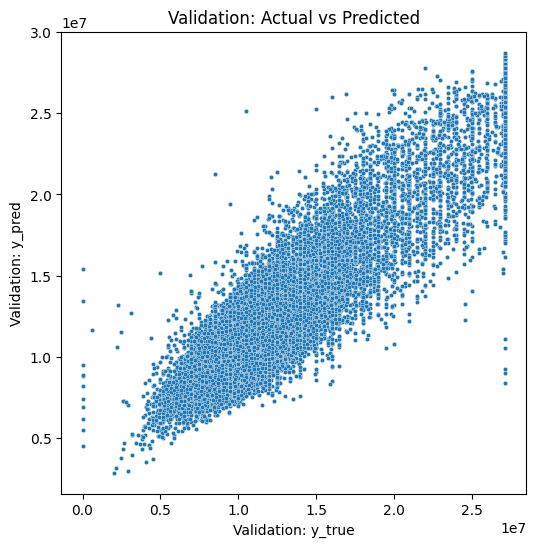

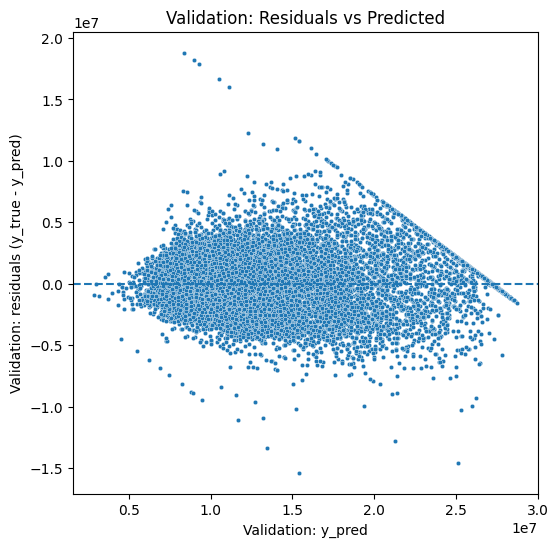

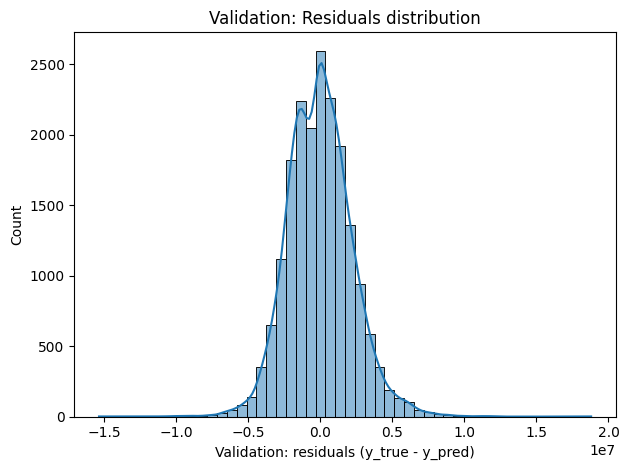

In [23]:
p_scatter_actual_vs_pred = plots_dir / "validation_actual_vs_pred.png"
p_scatter_resid_vs_pred = plots_dir / "validation_residuals_vs_pred.png"
p_val_resid = plots_dir / "validation_residuals_hist.png"


# 1) Validation: actual vs predicted
plt.figure(figsize=(6, 6))
sns.scatterplot(x=np.asarray(y_val), y=np.asarray(pred_val), s=10)
plt.xlabel("Validation: y_true")
plt.ylabel("Validation: y_pred")
plt.title("Validation: Actual vs Predicted")
plt.savefig(plots_dir / "validation_actual_vs_pred.png", dpi=150)
# plt.close()

# 2) Validation: residuals vs predicted
residuals_val = y_val - pred_val

plt.figure(figsize=(6, 6))
sns.scatterplot(x=np.asarray(pred_val), y=np.asarray(residuals_val), s=10)
plt.axhline(0, linestyle="--")
plt.xlabel("Validation: y_pred")
plt.ylabel("Validation: residuals (y_true - y_pred)")
plt.title("Validation: Residuals vs Predicted")
plt.savefig(plots_dir / "validation_residuals_vs_pred.png", dpi=150)
# plt.close()

# 3) Validation: residuals distribution
plt.figure()
sns.histplot(residuals_val, bins=50, kde=True)
plt.xlabel("Validation: residuals (y_true - y_pred)")
plt.ylabel("Count")
plt.title("Validation: Residuals distribution")
plt.tight_layout()
plt.savefig(plots_dir / "validation_residuals_hist.png", dpi=150)
# plt.close()





### Логирование артефактов в MLflow

In [24]:

run_name = "03_feature_generation"

summary_md = (
    "## Этап 3. Итог\n\n"
    f"- manual_features_added_cnt: {len(manual_added_cols)}\n"
    f"- manual_feature_names: {manual_added_cols}\n"
    f"- autofeat_added_cnt: {autofeat_added_cnt}\n"
    f"- n_features_final: {X_train_fe_final.shape[1]}\n"
    f"- RMSE={metrics['rmse']:.4f}, MAE={metrics['mae']:.4f}, R2={metrics['r2']:.4f}\n"
    f"- fit_time_sec={times['fit_time_sec']:.4f}, predict_time_sec={times['predict_time_sec']:.4f}\n"
)

stage3_dir = ART_DIR / "stage3"
stage3_dir.mkdir(exist_ok=True)
summary_path = stage3_dir / "stage3_summary.md"
summary_path.write_text(summary_md, encoding="utf-8")

with mlflow.start_run(run_name=run_name) as run:
    mlflow.set_tag("stage", "Stage3_FE")

    mlflow.log_param("table_name", TABLE_NAME)
    mlflow.log_param("target_col", TARGET_COL)
    mlflow.log_param("random_state", RANDOM_STATE)

    mlflow.log_param("manual_features_added_cnt", int(len(manual_added_cols)))
    mlflow.log_param("manual_feature_names", ",".join(manual_added_cols))

    mlflow.log_param("autofeat_added_cnt", int(autofeat_added_cnt))
    mlflow.log_param("autofeat_params", str(autofeat_params))

    mlflow.log_metrics(metrics)
    mlflow.log_metrics(times)


    if p_scatter_actual_vs_pred.exists():
        mlflow.log_artifact(str(p_scatter_actual_vs_pred), artifact_path="plots")
    if p_scatter_resid_vs_pred.exists():
        mlflow.log_artifact(str(p_scatter_resid_vs_pred), artifact_path="plots")
    if p_val_resid.exists():
        mlflow.log_artifact(str(p_val_resid), artifact_path="plots")

    mlflow.log_artifact(str(summary_path), artifact_path="reports")

    log_environment()
    if NOTEBOOK_PATH.exists():
        mlflow.log_artifact(str(NOTEBOOK_PATH), artifact_path="notebook")

    signature = infer_signature(X_test_fe_final.head(50), model.predict(X_test_fe_final.head(50)))
    model_info = mlflow.catboost.log_model(
        cb_model=model,
        artifact_path="model",
        signature=signature,
        input_example=X_test_fe_final.head(5),
        registered_model_name=REGISTERED_MODEL_NAME,
    )


client = MlflowClient()
versions = client.search_model_versions(f"name='{REGISTERED_MODEL_NAME}'")
versions_sorted = sorted(versions, key=lambda v: int(v.version))
new_v = versions_sorted[-1]
new_version = new_v.version

stage_code = "stage3_fe"          
stage_title = "Этап 3: генерация признаков"
short_recipe = "manual features added + autofeat"


client.set_model_version_tag(REGISTERED_MODEL_NAME, new_version, "stage", stage_code)
client.set_model_version_tag(REGISTERED_MODEL_NAME, new_version, "algo", "catboost")
client.set_model_version_tag(REGISTERED_MODEL_NAME, new_version, "feature_recipe", short_recipe)



desc = (
    f"{stage_title}\n"
    f"- Данные: {TABLE_NAME}, target={TARGET_COL}\n"
    f"- Рецепт признаков: {short_recipe}\n"
    f"- Метрики test: RMSE={metrics['rmse']:.4f}, MAE={metrics['mae']:.4f}, R2={metrics['r2']:.4f}\n"
    f"- Run: {run.info.run_id}\n"
)
client.update_model_version(
    name=REGISTERED_MODEL_NAME,
    version=new_version,
    description=desc
)

print("Model:", REGISTERED_MODEL_NAME)
print("Version:", new_version)
print("Stage tag:", stage_code)


Successfully registered model 'real_estate_price_model'.
2025/12/26 19:47:39 INFO mlflow.tracking._model_registry.client: Waiting up to 300 seconds for model version to finish creation. Model name: real_estate_price_model, version 1


Model: real_estate_price_model
Version: 1
Stage tag: stage3_fe


Created version '1' of model 'real_estate_price_model'.


## Этап 4: Отбор Признаков и Обучение Новой Версии Модели
Создание новых признаков — это лишь часть работы. Следующий важный шаг — это убедиться в том, что каждый из этих признаков действительно вносит положительный вклад в качество модели. Некоторые признаки могут оказывать отрицательное влияние на модель, поэтому их следует исключить из анализа.

На этом этапе, мы рекомендуем вам применить различные методы отбора признаков для того, чтобы определить и удалить те признаки, которые не улучшают качество вашей модели. Цель этого этапа — максимизировать производительность модели, удалив избыточные или неинформативные признаки.

После тщательного отбора признаков, пора обучить новую версию вашей модели, уже без негативно влияющих на неё признаков. Важно залогировать результаты этого этапа, включая измененный набор признаков, параметры модели и полученные метрики качества, в MLflow для последующего анализа и сравнения.

Рекомендуемые шаги:

- Применение методов отбора признаков для идентификации и исключения признаков, ухудшающих качество модели.
- Анализ влияния каждого признака на модель, чтобы понять, какие из них наиболее ценные.
- Обучение новой версии модели без негативно влияющих признаков.
- Логирование всех изменений и результатов в MLflow, включая конечный набор признаков, параметры модели и метрики качества.

Этот этап не только поможет улучшить качество вашей модели, но и даст глубокое понимание о важности и влиянии отдельных признаков на результаты моделирования.


In [25]:
stage4_dir = ART_DIR / "stage4"
plots_dir = stage4_dir / "plots"
fs_dir = stage4_dir / "feature_selection"

plots_dir.mkdir(parents=True, exist_ok=True)
fs_dir.mkdir(parents=True, exist_ok=True)

assert len(X_train_fe_final) == len(y_train_full)
assert len(X_val_fe_final) == len(y_val)
assert len(X_test_fe_final) == len(y_test)

print("Train:", X_train_fe_final.shape)
print("Val:", X_val_fe_final.shape)
print("Test:", X_test_fe_final.shape)


Train: (95617, 50)
Val: (19124, 50)
Test: (23905, 50)


### Отбор признаков при помощи метода номер 1

In [26]:
TOP_N = min(60, X_train_fe_final.shape[1])
K_FEATURES = min(20, TOP_N)

y_tr_s = pd.Series(np.asarray(y_train_full), index=X_train_fe_final.index, name=TARGET_COL)

corr = pd.concat([X_train_fe_final, y_tr_s], axis=1).corr(numeric_only=True)[TARGET_COL]
corr = corr.drop(labels=[TARGET_COL], errors="ignore").abs().sort_values(ascending=False)

top_features = corr.head(TOP_N).index.tolist()

X_tr_top = X_train_fe_final[top_features]
X_va_top = X_val_fe_final[top_features]

X_sfs = pd.concat([X_tr_top, X_va_top], axis=0)
y_sfs = np.concatenate([np.asarray(y_train_full), np.asarray(y_val)])

test_fold = np.array([-1] * len(X_tr_top) + [0] * len(X_va_top))
ps = PredefinedSplit(test_fold=test_fold)

print("TOP_N:", TOP_N, "K_FEATURES:", K_FEATURES)
print("Top sample:", top_features[:10])



TOP_N: 50 K_FEATURES: 20
Top sample: ['total_area', 'living_area', 'rooms', 'ceiling_height', 'kitchen_area', 'living_area*total_area', 'ce__building_type_int', 'ceiling_height*living_area', 'ce__building_type_int*has_elevator', 'build_year*building_age']


In [27]:
est = HistGradientBoostingRegressor(random_state=RANDOM_STATE, max_depth=6)

sfs_forward = SequentialFeatureSelector(
    estimator=est,
    k_features=K_FEATURES,
    forward=True,
    floating=False,
    scoring="neg_root_mean_squared_error",
    cv=ps,
    n_jobs=1,
)

t0 = time.perf_counter()
sfs_forward.fit(X_sfs.values, y_sfs)
sfs_time_sec = float(time.perf_counter() - t0)

selected_idx_sbs_local = list(sfs_forward.k_feature_idx_)
selected_features_sbs = [top_features[i] for i in selected_idx_sbs_local]

print("SFS selected cnt:", len(selected_features_sbs))
print("SFS time sec:", sfs_time_sec)
selected_features_sbs[:15]


SFS selected cnt: 20
SFS time sec: 1015.1385313860001


['total_area',
 'ceiling_height',
 'kitchen_area',
 'ce__building_type_int',
 'build_year*floors_total',
 'floor',
 'build_year',
 'building_age',
 'longitude',
 'is_first_floor',
 'has_elevator*is_first_floor',
 'build_year*living_area',
 'kitchen_area*latitude',
 'ceiling_height*is_apartment',
 'is_first_floor*total_area']

/home/mle_projects/MLflow_projects/MLFLOW_PROJECT/.venv_project_name/lib/python3.10/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/mle_projects/MLflow_projects/MLFLOW_PROJECT/.venv_project_name/lib/python3.10/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


PosixPath('artifacts/stage4/plots/stage4_sfs_forward_rmse_vs_k.png')

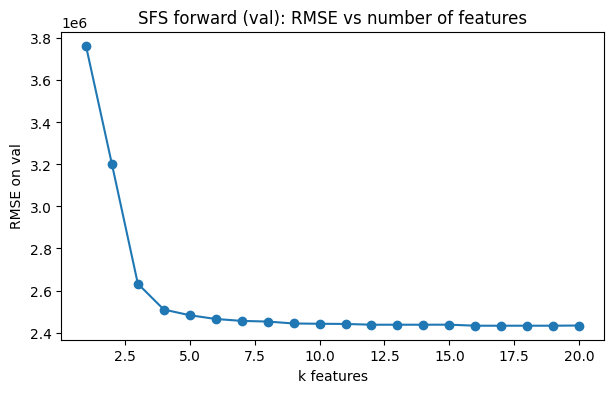

In [28]:
md = sfs_forward.get_metric_dict()

k_list = []
rmse_list = []
for k, v in md.items():
    k_list.append(int(k))
    rmse_list.append(float(-v["avg_score"]))

p_sfs = plots_dir / "stage4_sfs_forward_rmse_vs_k.png"
plt.figure(figsize=(7, 4))
plt.plot(k_list, rmse_list, marker="o")
plt.title("SFS forward (val): RMSE vs number of features")
plt.xlabel("k features")
plt.ylabel("RMSE on val")
plt.savefig(p_sfs, dpi=150, bbox_inches="tight")
# plt.close()

p_sfs


In [29]:
# TOP_N = min(40, X_train_fe_final.shape[1])
# K_FEATURES = min(20, TOP_N)

# y_tr_s = pd.Series(np.asarray(y_train_full), index=X_train_fe_final.index, name=TARGET_COL)

# corr = pd.concat(
#     [X_train_fe_final, y_tr_s],
#     axis=1
# ).corr(numeric_only=True)[TARGET_COL].drop(labels=[TARGET_COL], errors="ignore").abs().sort_values(ascending=False)

# top_features = corr.head(TOP_N).index.tolist()

# X_sfs_top = X_sfs[top_features]
# X_tr_top = X_train_fe_final[top_features]
# X_va_top = X_val_fe_final[top_features]
# X_te_top = X_test_fe_final[top_features]

# print("TOP_N:", TOP_N, "K_FEATURES:", K_FEATURES)
# print("Top sample:", top_features[:10])


In [30]:
# est = HistGradientBoostingRegressor(random_state=42, max_depth=6)
# sfs_forward = SequentialFeatureSelector(
#     estimator=est,
#     k_features=K_FEATURES,
#     forward=True,
#     floating=False,
#     scoring="neg_root_mean_squared_error",
#     cv=2,
#     n_jobs=-1,
# )




In [31]:
# t0 = time.perf_counter()
# sfs_forward.fit(X_tr_top.values, y_train_full)
# forward_time_sec = float(time.perf_counter() - t0)



In [32]:
# forward_idx = list(sfs_forward.k_feature_idx_)
# forward_features = [top_features[i] for i in forward_idx]
# forward_val_rmse = float(-sfs_forward.k_score_)

# print("Forward val RMSE:", forward_val_rmse)
# print("Forward cnt:", len(forward_features))

### Отбор признаков при помощи метода номер 2

In [33]:
M_IMPORTANCE = min(20, X_train_fe_final.shape[1])

cb_imp_model = CatBoostRegressor(
    iterations=400,
    learning_rate=0.1,
    depth=8,
    loss_function="RMSE",
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False,
)

cb_imp_model.fit(X_train_fe_final, y_train_full)

imp_vals = cb_imp_model.get_feature_importance(type="PredictionValuesChange")
imp_series = pd.Series(imp_vals, index=X_train_fe_final.columns).sort_values(ascending=False)

selected_features_cb = imp_series.head(M_IMPORTANCE).index.tolist()

print("CatBoost top cnt:", len(selected_features_cb))
selected_features_cb[:15]



CatBoost top cnt: 20


['total_area',
 'latitude',
 'longitude',
 'latitude*longitude',
 'ceiling_height',
 'is_first_floor*total_area',
 'living_area*total_area',
 'ce__building_type_int*has_elevator',
 'kitchen_area',
 'building_age',
 'building_age*latitude',
 'ceiling_height*living_area',
 'ceiling_height*latitude',
 'rooms',
 'build_year*longitude']

PosixPath('artifacts/stage4/plots/stage4_catboost_importance_top20.png')

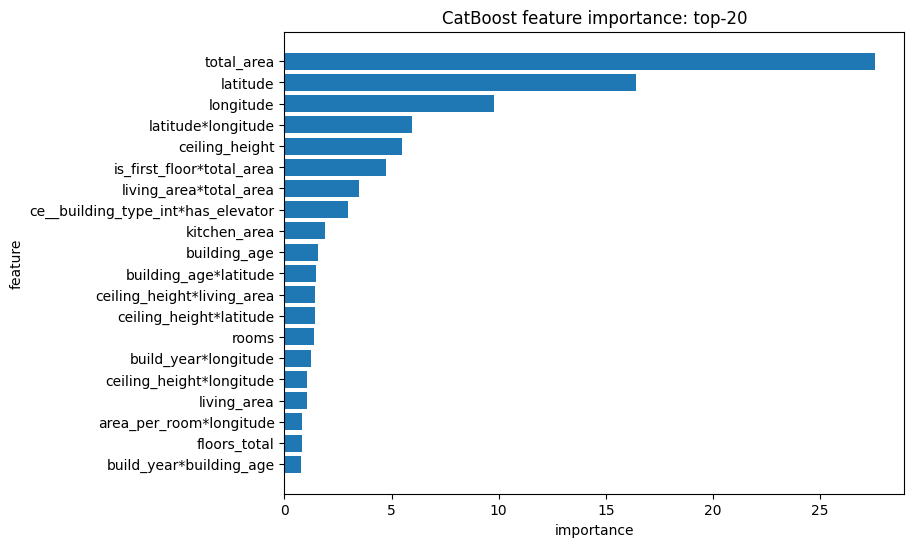

In [34]:
top_imp = imp_series.head(20).sort_values(ascending=True)

p_imp = plots_dir / "stage4_catboost_importance_top20.png"
plt.figure(figsize=(8, 6))
plt.barh(top_imp.index, top_imp.values)
plt.title("CatBoost feature importance: top-20")
plt.xlabel("importance")
plt.ylabel("feature")
plt.savefig(p_imp, dpi=150, bbox_inches="tight")
# plt.close()

p_imp


### Анализ отобранных признаков при помощи двух методов и формирование финального списка с признаками для модели

In [35]:
feature_cols = list(X_train_fe_final.columns)
name_to_idx = {c: i for i, c in enumerate(feature_cols)}

selected_idx_sbs = [name_to_idx[c] for c in selected_features_sbs if c in name_to_idx]
selected_idx_cb = [name_to_idx[c] for c in selected_features_cb if c in name_to_idx]

selected_features = sorted(set(selected_idx_sbs).union(set(selected_idx_cb)))
selected_feature_names = [feature_cols[i] for i in selected_features]

overlap_cnt = len(set(selected_idx_sbs).intersection(set(selected_idx_cb)))

print("SFS idx cnt:", len(selected_idx_sbs))
print("CB idx cnt:", len(selected_idx_cb))
print("Overlap cnt:", overlap_cnt)
print("Union cnt:", len(selected_features))


SFS idx cnt: 20
CB idx cnt: 20
Overlap cnt: 7
Union cnt: 33


In [36]:
import json

In [37]:
(fs_dir / "selected_idx_sbs.json").write_text(json.dumps(selected_idx_sbs, indent=2), encoding="utf-8")
(fs_dir / "selected_idx_cb.json").write_text(json.dumps(selected_idx_cb, indent=2), encoding="utf-8")
(fs_dir / "selected_idx_union.json").write_text(json.dumps(selected_features, indent=2), encoding="utf-8")

(fs_dir / "selected_features_sbs.json").write_text(json.dumps(selected_features_sbs, ensure_ascii=False, indent=2), encoding="utf-8")
(fs_dir / "selected_features_cb.json").write_text(json.dumps(selected_features_cb, ensure_ascii=False, indent=2), encoding="utf-8")
(fs_dir / "selected_features_union.json").write_text(json.dumps(selected_feature_names, ensure_ascii=False, indent=2), encoding="utf-8")

print("Saved feature lists into:", fs_dir)


Saved feature lists into: artifacts/stage4/feature_selection


### Обучение новой версии модели

In [38]:
def fit_eval_on_val(feature_names, label):
    Xtr = X_train_fe_final[feature_names]
    Xva = X_val_fe_final[feature_names]

    model = CatBoostRegressor(
        iterations=400,
        learning_rate=0.1,
        depth=8,
        loss_function="RMSE",
        random_seed=RANDOM_STATE,
        verbose=False,
        allow_writing_files=False,
    )

    t0 = time.perf_counter()
    model.fit(Xtr, y_train_full)
    fit_time_sec = float(time.perf_counter() - t0)

    t1 = time.perf_counter()
    pred_val = model.predict(Xva)
    predict_time_sec = float(time.perf_counter() - t1)

    rmse_val = float(root_mean_squared_error(y_val, pred_val))
    mae_val = float(mean_absolute_error(y_val, pred_val))
    r2_val = float(r2_score(y_val, pred_val))

    return {
        "label": label,
        "n_features": len(feature_names),
        "rmse_val": rmse_val,
        "mae_val": mae_val,
        "r2_val": r2_val,
        "fit_time_sec": fit_time_sec,
        "predict_time_sec": predict_time_sec,
        "model": model,
        "features": feature_names,
    }

res_sbs = fit_eval_on_val(selected_features_sbs, "SFS_forward")
res_cb = fit_eval_on_val(selected_features_cb, "CatBoost_importance")
res_union = fit_eval_on_val(selected_feature_names, "Union")

val_results = pd.DataFrame([
    {k: v for k, v in res_sbs.items() if k not in ["model", "features"]},
    {k: v for k, v in res_cb.items() if k not in ["model", "features"]},
    {k: v for k, v in res_union.items() if k not in ["model", "features"]},
]).sort_values("rmse_val")

val_results


,label,n_features,rmse_val,mae_val,r2_val,fit_time_sec,predict_time_sec
2,Union,33,2.263644e+06,1.746406e+06,0.865462,17.936773,0.044918
1,CatBoost_importance,20,2.272629e+06,1.752439e+06,0.864392,14.956297,0.014988
0,SFS_forward,20,2.293352e+06,1.764726e+06,0.861907,14.545628,0.014674


PosixPath('artifacts/stage4/plots/stage4_val_rmse_comparison.png')

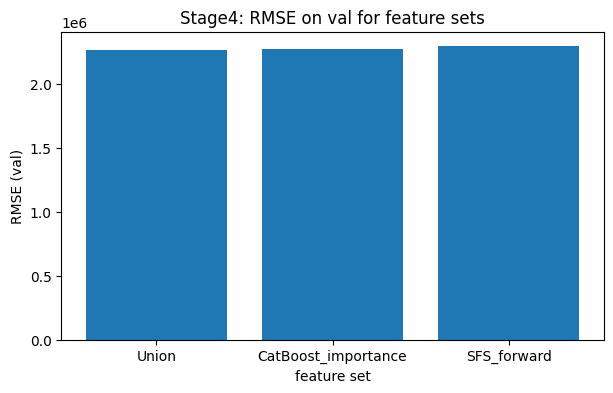

In [39]:
p_val_cmp = plots_dir / "stage4_val_rmse_comparison.png"

tmp = val_results.sort_values("rmse_val", ascending=True)
plt.figure(figsize=(7, 4))
plt.bar(tmp["label"], tmp["rmse_val"])
plt.title("Stage4: RMSE on val for feature sets")
plt.xlabel("feature set")
plt.ylabel("RMSE (val)")
plt.savefig(p_val_cmp, dpi=150, bbox_inches="tight")
# plt.close()

p_val_cmp


### Логирование всех артефактов в MLflow

In [40]:

stage4_dir = ART_DIR / "stage4"
plots_dir = stage4_dir / "plots"
fs_dir = stage4_dir / "feature_selection"
reports_dir = stage4_dir / "reports"

plots_dir.mkdir(parents=True, exist_ok=True)
fs_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)

run_name = "04_feature_selection"

# выбираем лучший набор по RMSE на val
best_label = val_results.sort_values("rmse_val", ascending=True).iloc[0]["label"]
best_pack = {"SFS_forward": res_sbs, "CatBoost_importance": res_cb, "Union": res_union}[best_label]
best_features = best_pack["features"]

# финальное обучение на train+val
X_trainval = pd.concat(
    [X_train_fe_final[best_features], X_val_fe_final[best_features]],
    axis=0
)
y_trainval = np.concatenate([np.asarray(y_train_full), np.asarray(y_val)])

Xte = X_test_fe_final[best_features]

final_model = CatBoostRegressor(
    iterations=400,
    learning_rate=0.1,
    depth=8,
    loss_function="RMSE",
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False,
)

t0 = time.perf_counter()
final_model.fit(X_trainval, y_trainval)
fit_time_sec = float(time.perf_counter() - t0)

t1 = time.perf_counter()
pred_test = final_model.predict(Xte)
predict_time_sec = float(time.perf_counter() - t1)

rmse_test = float(root_mean_squared_error(y_test, pred_test))
mae_test = float(mean_absolute_error(y_test, pred_test))
r2_test = float(r2_score(y_test, pred_test))

# графики на test
p_scatter = plots_dir / "stage4_test_true_vs_pred.png"
plt.figure(figsize=(6, 6))
sns.scatterplot(x=np.asarray(y_test), y=np.asarray(pred_test), s=10)
plt.title("Stage4 test: y_true vs y_pred")
plt.xlabel("y_true")
plt.ylabel("y_pred")
plt.savefig(p_scatter, dpi=150, bbox_inches="tight")
plt.close()

p_resid = plots_dir / "stage4_test_residuals_hist.png"
resid = np.asarray(y_test) - np.asarray(pred_test)
plt.figure(figsize=(8, 4))
sns.histplot(resid, bins=50, kde=True)
plt.title("Stage4 test: residuals")
plt.xlabel("y_true - y_pred")
plt.ylabel("count")
plt.savefig(p_resid, dpi=150, bbox_inches="tight")
plt.close()


p_val_table = reports_dir / "val_results.csv"
val_results.to_csv(p_val_table, index=False)

# summary
summary_md = (
    "## Этап 4. Итог\n\n"
    f"- experiment: {EXPERIMENT_NAME}\n"
    f"- run_name: {run_name}\n"
    f"- table_name: {TABLE_NAME}\n"
    f"- target: {TARGET_COL}\n"
    f"- random_state: {RANDOM_STATE}\n\n"
    "### Выбор набора признаков по val\n"
    f"- best_set: {best_label}\n"
    f"- n_features: {len(best_features)}\n"
    f"- rmse_val(best): {float(val_results[val_results['label']==best_label]['rmse_val'].iloc[0]):.4f}\n\n"
    "### Финальная оценка на test\n"
    f"- rmse_test: {rmse_test:.4f}\n"
    f"- mae_test: {mae_test:.4f}\n"
    f"- r2_test: {r2_test:.4f}\n"
    f"- fit_time_sec: {fit_time_sec:.4f}\n"
    f"- predict_time_sec: {predict_time_sec:.4f}\n"
)
p_summary = reports_dir / "stage4_summary.md"
p_summary.write_text(summary_md, encoding="utf-8")

# MLflow logging + registration
import mlflow
from mlflow.models import infer_signature
from mlflow.tracking import MlflowClient

with mlflow.start_run(run_name=run_name) as run:
    mlflow.set_tag("stage", "Stage4_FS")
    mlflow.set_tag("fs_method_1", "mlxtend_sfs_forward_hgbr")
    mlflow.set_tag("fs_method_2", "catboost_feature_importance")
    mlflow.set_tag("selection_rule", "best_rmse_on_val_then_fit_train_plus_val_eval_test")


    mlflow.log_param("table_name", TABLE_NAME)
    mlflow.log_param("target_col", TARGET_COL)
    mlflow.log_param("random_state", RANDOM_STATE)
    mlflow.log_param("best_set_by_val", best_label)
    mlflow.log_param("n_features_final", int(len(best_features)))
    mlflow.log_text("\n".join(best_features), "feature_selection/final_feature_names.txt")




    mlflow.log_metric("rmse", rmse_test)
    mlflow.log_metric("mae", mae_test)
    mlflow.log_metric("r2", r2_test)

    for p in [
        fs_dir / "selected_idx_sbs.json",
        fs_dir / "selected_idx_cb.json",
        fs_dir / "selected_idx_union.json",
        fs_dir / "selected_features_sbs.json",
        fs_dir / "selected_features_cb.json",
        fs_dir / "selected_features_union.json",
    ]:
        if p.exists():
            mlflow.log_artifact(str(p), artifact_path="feature_selection")

    # артефакты: таблица и summary
    mlflow.log_artifact(str(p_val_table), artifact_path="reports")
    mlflow.log_artifact(str(p_summary), artifact_path="reports")

    # артефакты: графики
    for p in [p_scatter, p_resid]:
        if p.exists():
            mlflow.log_artifact(str(p), artifact_path="plots")

    # окружение
    log_environment()

    # ноутбук
    if NOTEBOOK_PATH.exists():
        mlflow.log_artifact(str(NOTEBOOK_PATH), artifact_path="notebook")

    # модель: логирование и регистрация
    signature = infer_signature(Xte.head(50), final_model.predict(Xte.head(50)))
    model_info = mlflow.catboost.log_model(
        cb_model=final_model,
        artifact_path="model",
        signature=signature,
        input_example=Xte.head(5),
        registered_model_name=REGISTERED_MODEL_NAME,
    )

client = MlflowClient()
versions = client.search_model_versions(f"name='{REGISTERED_MODEL_NAME}'")
versions_sorted = sorted(versions, key=lambda v: int(v.version))
new_v = versions_sorted[-1]
new_version = new_v.version

stage_code = "stage4_fs"         
stage_title = "Этап 4: отбор признаков"
short_recipe = "SFS forward (HGBR) + CatBoost importance, union, fit train+val"

# Теги на уровне версии в Registry
client.set_model_version_tag(REGISTERED_MODEL_NAME, new_version, "stage", stage_code)
client.set_model_version_tag(REGISTERED_MODEL_NAME, new_version, "algo", "catboost")
client.set_model_version_tag(REGISTERED_MODEL_NAME, new_version, "feature_recipe", short_recipe)



desc = (
    f"{stage_title}\n"
    f"- Данные: {TABLE_NAME}, target={TARGET_COL}\n"
    f"- Рецепт признаков: {short_recipe}\n"
    f"- Метрики test: RMSE={rmse_test:.4f}, MAE={mae_test:.4f}, R2={r2_test:.4f}\n"
    f"- Run: {run.info.run_id}\n"
)
client.update_model_version(
    name=REGISTERED_MODEL_NAME,
    version=new_version,
    description=desc
)


print("Model:", REGISTERED_MODEL_NAME)
print("Version:", new_version)
print("Stage tag:", stage_code)


Registered model 'real_estate_price_model' already exists. Creating a new version of this model...
2025/12/26 20:06:26 INFO mlflow.tracking._model_registry.client: Waiting up to 300 seconds for model version to finish creation. Model name: real_estate_price_model, version 2


Model: real_estate_price_model
Version: 2
Stage tag: stage4_fs


Created version '2' of model 'real_estate_price_model'.


## Этап 5 - подбор гиперпараметров и обучение новой версии модели
После того как мы уделили значительное внимание качеству модели через создание и отбор признаков, пришло время для финального штриха — подбора гиперпараметров. Этот этап является ключевым в финальной части проекта второго спринта, где ваша задача — оптимизировать гиперпараметры модели для достижения наилучшего качества.

Рекомендуется подобрать гиперпараметры как минимум двумя различными методами (например, с использованием Grid Search и Random Search), чтобы вы могли сравнить результаты и выбрать наиболее эффективный набор гиперпараметров для вашей модели. После определения оптимальных гиперпараметров, наступает время обучить финальную версию модели, используя ваши новые признаки.

Рекомендуемые шаги:

- Выбор методов для подбора гиперпараметров: Определитесь с методами, которые вы будете использовать для подбора гиперпараметров (например, Grid Search, Random Search, Bayesian Optimization).
- Подбор гиперпараметров: Примените выбранные методы для нахождения оптимальных значений гиперпараметров вашей модели.
- Сравнение результатов: Анализируйте и сравнивайте результаты, полученные различными методами, для определения наилучшего набора гиперпараметров.
- Обучение финальной модели: Используя выбранные гиперпараметры, обучите финальную версию вашей модели на новых признаках.
- Документирование процесса и результатов: Залогируйте все шаги и результаты в MLflow, включая сравнение методов подбора гиперпараметров и характеристики финальной модели.

Этот этап позволит вам максимально улучшить качество вашей модели перед финальной оценкой, предоставив полное понимание важности и влияния гиперпараметров на производительность модели.

In [47]:

X_tr = X_train_fe_final.iloc[:, selected_features]
X_va = X_val_fe_final.iloc[:, selected_features]
X_te = X_test_fe_final.iloc[:, selected_features]

print("Stage5 shapes:")
print("  X_tr:", X_tr.shape, "X_va:", X_va.shape, "X_te:", X_te.shape)
print("  n_final_features:", len(selected_features))


Stage5 shapes:
  X_tr: (95617, 33) X_va: (19124, 33) X_te: (23905, 33)
  n_final_features: 33


### Подбор гиперпарметров при мощи метода номер 1

(95617, 33)

/tmp/ipykernel_61526/3287007957.py:54: ExperimentalWarning: MLflowCallback is experimental (supported from v1.4.0). The interface can change in the future.
  mlflc = MLflowCallback(
[I 2025-12-26 21:05:39,635] A new study created in memory with name: stage5_optuna


[I 2025-12-26 21:05:54,286] Trial 0 finished with value: 2438407.920146085 and parameters: {'iterations': 491, 'depth': 6, 'learning_rate': 0.055947100427442165, 'l2_leaf_reg': 3.4668305008472124, 'subsample': 0.8343082165293972, 'colsample_bylevel': 0.9182637931779589, 'random_strength': 1.141958129314517, 'min_data_in_leaf': 49}. Best is trial 0 with value: 2438407.920146085.
[I 2025-12-26 21:07:13,227] Trial 1 finished with value: 2256202.2863534414 and parameters: {'iterations': 2395, 'depth': 6, 'learning_rate': 0.03890324293425103, 'l2_leaf_reg': 5.0280581632697094, 'subsample': 0.8396323949913351, 'colsample_bylevel': 0.6509640492693647, 'random_strength': 0.8233649181746132, 'min_data_in_leaf': 38}. Best is trial 1 with value: 2256202.2863534414.
[I 2025-12-26 21:07:28,398] Trial 2 finished with value: 2414215.5098579214 and parameters: {'iterations': 552, 'depth': 6, 'learning_rate': 0.059070909994140185, 'l2_leaf_reg': 4.323948361116887, 'subsample': 0.8408804102729945, 'cols

Optuna done
  best_rmse_val: 2031021.6907779737
  best_params keys: ['iterations', 'depth', 'learning_rate', 'l2_leaf_reg', 'subsample', 'colsample_bylevel', 'random_strength', 'min_data_in_leaf']
  time_sec: 534.9888277110003


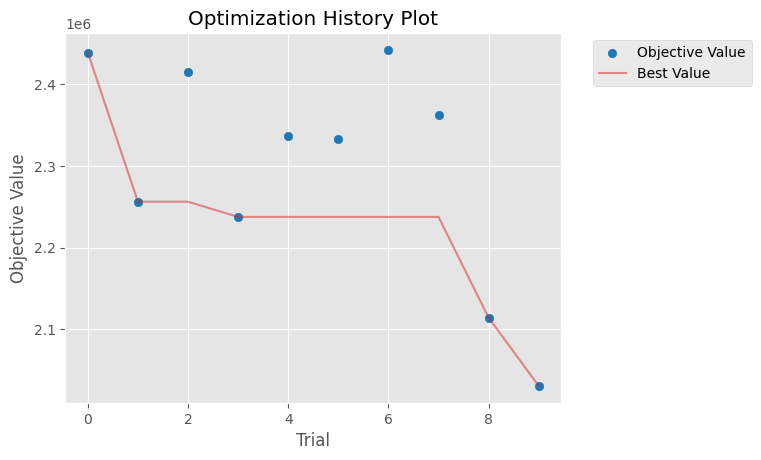

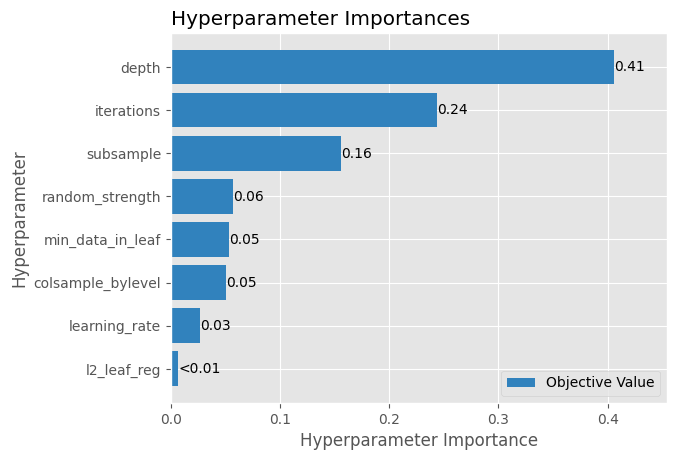

In [ ]:
stage5_dir = ART_DIR / "stage5"
plots_dir = stage5_dir / "plots"
reports_dir = stage5_dir / "reports"
plots_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)

N_TRIALS = 10



def objective_optuna(trial):
    params = {
        
        "iterations": trial.suggest_int("iterations", 400, 3000),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.2, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 80.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.6, 1.0),

        
        "random_strength": trial.suggest_float("random_strength", 0.0, 2.0),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 64),

        
        "eval_metric": "RMSE",
    }

    model = CatBoostRegressor(
        loss_function="RMSE",
        random_seed=RANDOM_STATE,
        verbose=False,
        allow_writing_files=False,
        **params
    )

    model.fit(
        X_tr, y_train_full,
        eval_set=(X_va, y_val),
        use_best_model=True,
        early_stopping_rounds=100
    )

    pred_val = model.predict(X_va)
    rmse_val = root_mean_squared_error(y_val, pred_val)
    return rmse_val

# Optuna study + MLflow callback
setup_mlflow()

# callback_used = False
# try:
#     from optuna.integration.mlflow import MLflowCallback
#     mlflc = MLflowCallback(
#         tracking_uri=mlflow.get_tracking_uri(),
#         metric_name="rmse_val"
#     )
#     callback_used = True
# except Exception as e:
#     mlflc = None
#     print("MLflowCallback не доступен, Optuna пойдет без callback. Ошибка:", repr(e))

t0 = time.perf_counter()
study = optuna.create_study(direction="minimize", study_name="stage5_optuna")

# if callback_used:
#     study.optimize(objective_optuna, n_trials=N_TRIALS, callbacks=[mlflc])
# else:
study.optimize(objective_optuna, n_trials=N_TRIALS)
optuna_time_sec = float(time.perf_counter() - t0)

best_params_optuna = dict(study.best_params)
best_rmse_val_optuna = float(study.best_value)

# сохраняем best params
p_optuna_params = reports_dir / "best_params_optuna.json"
p_optuna_params.write_text(json.dumps(best_params_optuna, ensure_ascii=False, indent=2), encoding="utf-8")

# графики Optuna (если доступны)
p_optuna_hist = plots_dir / "optuna_optimization_history.png"
p_optuna_imp = plots_dir / "optuna_param_importances.png"

try:
    from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances

    fig1 = plot_optimization_history(study)
    fig1.figure.savefig(p_optuna_hist, dpi=150, bbox_inches="tight")

    fig2 = plot_param_importances(study)
    fig2.figure.savefig(p_optuna_imp, dpi=150, bbox_inches="tight")
except Exception as e:
    print("Optuna matplotlib plots не удалось построить. Ошибка:", repr(e))

print("Optuna done")
print("  best_rmse_val:", best_rmse_val_optuna)
print("  best_params keys:", list(best_params_optuna.keys()))
print("  time_sec:", optuna_time_sec)


### Подбор гиперпарметров при мощи метода номер 2

In [ ]:
# объединяем train+val, чтобы sklearn-search видел разбиение через PredefinedSplit
X_all = pd.concat([X_tr, X_va], axis=0)
y_all = np.concatenate([np.asarray(y_train_full), np.asarray(y_val)])

fold = np.concatenate([
    -1 * np.ones(len(X_tr), dtype=int),
    0 * np.ones(len(X_va), dtype=int)
])
ps = PredefinedSplit(test_fold=fold)

est_base = CatBoostRegressor(
    loss_function="RMSE",
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False
)


param_dist = {
    "iterations": [300, 500, 800, 1100],
    "depth": [4, 6, 8],
    "learning_rate": [0.08, 0.1, 0.15],
    "l2_leaf_reg": [1, 3, 5, 10, 20, 40],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bylevel": [0.7, 0.8, 0.9, 1.0],
}

N_ITER_SEARCH = 20

t1 = time.perf_counter()
rs = RandomizedSearchCV(
    estimator=est_base,
    param_distributions=param_dist,
    n_iter=N_ITER_SEARCH,
    scoring="neg_root_mean_squared_error",
    cv=3,
    refit=False,
    n_jobs=1,
    random_state=RANDOM_STATE,
    verbose=2,
)
rs.fit(X_all, y_all)
search_time_sec = float(time.perf_counter() - t1)

best_params_search = dict(rs.best_params_)
best_rmse_val_search = float(-rs.best_score_)

p_search_params = reports_dir / "best_params_search.json"
p_search_params.write_text(json.dumps(best_params_search, ensure_ascii=False, indent=2), encoding="utf-8")

print("Search done")
print("  best_rmse_val:", best_rmse_val_search)
print("  best_params keys:", list(best_params_search.keys()))
print("  time_sec:", search_time_sec)

Fitting 1 folds for each of 20 candidates, totalling 20 fits
[CV] END colsample_bylevel=0.8, depth=6, iterations=500, l2_leaf_reg=40, learning_rate=0.1, min_data_in_leaf=1, subsample=1.0; total time=  16.5s
[CV] END colsample_bylevel=0.7, depth=4, iterations=500, l2_leaf_reg=3, learning_rate=0.02, min_data_in_leaf=64, subsample=0.7; total time=  10.1s
[CV] END colsample_bylevel=1.0, depth=6, iterations=300, l2_leaf_reg=40, learning_rate=0.15, min_data_in_leaf=64, subsample=0.9; total time=   8.2s
[CV] END colsample_bylevel=1.0, depth=10, iterations=800, l2_leaf_reg=1, learning_rate=0.1, min_data_in_leaf=64, subsample=0.7; total time= 1.8min
[CV] END colsample_bylevel=0.7, depth=10, iterations=1100, l2_leaf_reg=20, learning_rate=0.02, min_data_in_leaf=4, subsample=0.7; total time= 1.8min
[CV] END colsample_bylevel=0.7, depth=8, iterations=300, l2_leaf_reg=20, learning_rate=0.05, min_data_in_leaf=1, subsample=0.8; total time=  18.2s
[CV] END colsample_bylevel=0.8, depth=6, iterations=110

156

### Формирование списка гиперпараметров для новой модели

In [ ]:
def eval_on_val(params):
    model = CatBoostRegressor(
        loss_function="RMSE",
        random_seed=RANDOM_STATE,
        verbose=False,
        allow_writing_files=False,
        early_stopping_rounds=100,
        **params
    )
    model.fit(X_tr, y_train_full)
    pred = model.predict(X_va)
    rmse = float(root_mean_squared_error(y_val, pred))
    mae = float(mean_absolute_error(y_val, pred))
    r2 = float(r2_score(y_val, pred))
    return rmse, mae, r2

rmse_o, mae_o, r2_o = eval_on_val(best_params_optuna)
rmse_s, mae_s, r2_s = eval_on_val(best_params_search)

results_stage5 = pd.DataFrame([
    {"method": "optuna", "rmse_val": rmse_o, "mae_val": mae_o, "r2_val": r2_o, "time_sec": optuna_time_sec, "n_candidates": N_TRIALS},
    {"method": "search", "rmse_val": rmse_s, "mae_val": mae_s, "r2_val": r2_s, "time_sec": search_time_sec, "n_candidates": N_ITER_SEARCH},
]).sort_values("rmse_val", ascending=True)

best_method = results_stage5.iloc[0]["method"]
best_params_final = best_params_optuna if best_method == "optuna" else best_params_search

p_final_params = reports_dir / "best_params_final.json"
p_final_params.write_text(json.dumps(best_params_final, ensure_ascii=False, indent=2), encoding="utf-8")

print(results_stage5)
print("Best method:", best_method)
print("Saved:", p_final_params)


   method      rmse_val       mae_val    r2_val    time_sec  n_candidates
1  search  1.823269e+06  1.397974e+06  0.912717  749.266351            20
0  optuna  1.976748e+06  1.527530e+06  0.897404  328.884914            10
Best method: search
Saved: artifacts/stage5/reports/best_params_final.json


### Обуение финальной версии модели

Final test metrics:
  rmse: 2307440.7541923393
  mae: 1732828.4004817554
  r2: 0.8621653379459189
Times:
  fit_time_sec: 133.53840608999963
  predict_time_sec: 0.16785420300038822


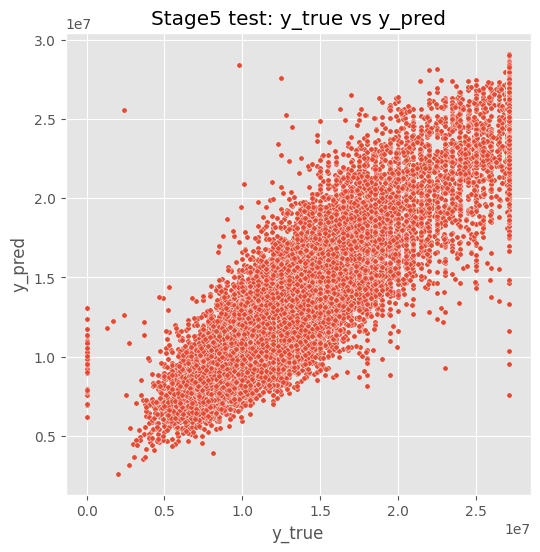

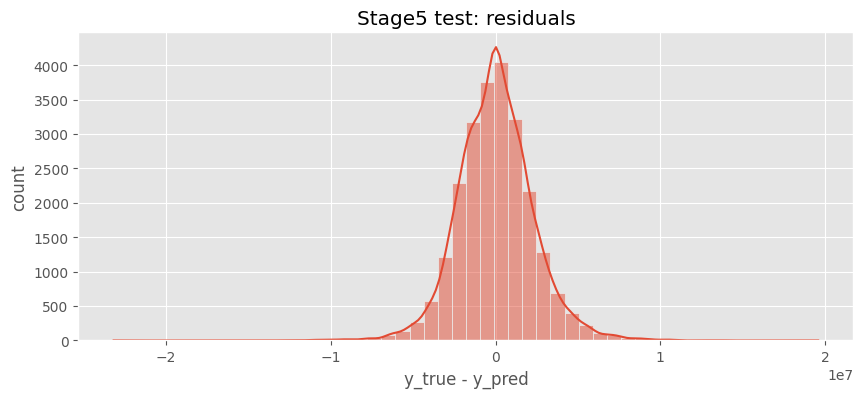

In [66]:
X_trainval = pd.concat([X_tr, X_va], axis=0)
y_trainval = np.concatenate([np.asarray(y_train_full), np.asarray(y_val)])

final_model = CatBoostRegressor(
    loss_function="RMSE",
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False,
    early_stopping_rounds=100,
    **best_params_final
)

t2 = time.perf_counter()
final_model.fit(X_trainval, y_trainval)
fit_time_sec = float(time.perf_counter() - t2)

t3 = time.perf_counter()
pred_test = final_model.predict(X_te)
predict_time_sec = float(time.perf_counter() - t3)

rmse_test = float(root_mean_squared_error(y_test, pred_test))
mae_test = float(mean_absolute_error(y_test, pred_test))
r2_test = float(r2_score(y_test, pred_test))

# графики
p_scatter = plots_dir / "stage5_test_true_vs_pred.png"
plt.figure(figsize=(6, 6))
sns.scatterplot(x=np.asarray(y_test), y=np.asarray(pred_test), s=15)
plt.title("Stage5 test: y_true vs y_pred")
plt.xlabel("y_true")
plt.ylabel("y_pred")
plt.savefig(p_scatter, dpi=150, bbox_inches="tight")
# plt.close()

p_resid = plots_dir / "stage5_test_residuals_hist.png"
resid = np.asarray(y_test) - np.asarray(pred_test)
plt.figure(figsize=(10, 4))
sns.histplot(resid, bins=50, kde=True)
plt.title("Stage5 test: residuals")
plt.xlabel("y_true - y_pred")
plt.ylabel("count")
plt.savefig(p_resid, dpi=150, bbox_inches="tight")
# plt.close()

print("Final test metrics:")
print("  rmse:", rmse_test)
print("  mae:", mae_test)
print("  r2:", r2_test)
print("Times:")
print("  fit_time_sec:", fit_time_sec)
print("  predict_time_sec:", predict_time_sec)


### Логирование артефактов в MLflow

In [67]:
setup_mlflow()

run_name = "05_hyperparameter_tuning"

# сохраняем summary
summary_md = (
    "## Этап 5. Итог\n\n"
    f"- experiment: {EXPERIMENT_NAME}\n"
    f"- table_name: {TABLE_NAME}\n"
    f"- target: {TARGET_COL}\n"
    f"- random_state: {RANDOM_STATE}\n"
    f"- final_features_cnt: {len(X_trainval.columns)}\n\n"
    "### Выбор метода на val\n"
    f"- best_method: {best_method}\n\n"
    "### Метрики на test\n"
    f"- rmse_test: {rmse_test:.6f}\n"
    f"- mae_test: {mae_test:.6f}\n"
    f"- r2_test: {r2_test:.6f}\n"
    f"- fit_time_sec: {fit_time_sec:.6f}\n"
    f"- predict_time_sec: {predict_time_sec:.6f}\n\n"
    "### Лучшие параметры\n"
    f"- best_params_final: {json.dumps(best_params_final, ensure_ascii=False)}\n"
)
p_summary = reports_dir / "stage5_summary.md"
p_summary.write_text(summary_md, encoding="utf-8")

# фиксируем список финальных фичей
p_feats = reports_dir / "final_features_used.txt"
p_feats.write_text("\n".join(X_trainval.columns), encoding="utf-8")

from mlflow.models import infer_signature
from mlflow.tracking import MlflowClient
from mlflow.protos.model_registry_pb2 import SetModelVersionTag

def detect_version_type():
    try:
        SetModelVersionTag(name="x", version="1", key="k", value="v")
        return "str"
    except TypeError:
        return "int"

def to_version_api_type(v):
    expected = detect_version_type()
    return str(v) if expected == "str" else int(v)

tuning_methods_label = "optuna+random_search"

with mlflow.start_run(run_name=run_name) as run:
    mlflow.set_tag("stage", "Stage5_Tuning")
    mlflow.set_tag("tuning_methods", tuning_methods_label)

    mlflow.log_param("table_name", TABLE_NAME)
    mlflow.log_param("target_col", TARGET_COL)
    mlflow.log_param("random_state", RANDOM_STATE)
    mlflow.log_param("final_features_cnt", int(len(X_trainval.columns)))
    mlflow.log_param("best_method_val", str(best_method))
    mlflow.log_param("tuning_methods", tuning_methods_label)

    # логируем best params как параметры MLflow
    for k, v in best_params_final.items():
        mlflow.log_param(f"best__{k}", v)

    mlflow.log_metric("rmse", rmse_test)
    mlflow.log_metric("mae", mae_test)
    mlflow.log_metric("r2", r2_test)
    mlflow.log_metric("fit_time_sec", fit_time_sec)
    mlflow.log_metric("predict_time_sec", predict_time_sec)

    # артефакты
    for p in [p_scatter, p_resid, p_optuna_hist, p_optuna_imp]:
        if p is not None and Path(p).exists():
            mlflow.log_artifact(str(p), artifact_path="plots")

    for p in [p_optuna_params, p_search_params, p_final_params, p_summary, p_feats]:
        if p is not None and Path(p).exists():
            mlflow.log_artifact(str(p), artifact_path="reports")

    # окружение и ноутбук
    log_environment()
    if NOTEBOOK_PATH.exists():
        mlflow.log_artifact(str(NOTEBOOK_PATH), artifact_path="notebook")

    # логирование и регистрация модели
    signature = infer_signature(X_te.head(50), pred_test[:50])
    model_info = mlflow.catboost.log_model(
        cb_model=final_model,
        artifact_path="model",
        signature=signature,
        input_example=X_te.head(5),
        registered_model_name=REGISTERED_MODEL_NAME,
    )

    # маркируем версию в Registry
    client = MlflowClient()
    model_name = str(REGISTERED_MODEL_NAME)

    versions = client.search_model_versions(f"name='{model_name}'")
    versions_this_run = [v for v in versions if getattr(v, "run_id", None) == run.info.run_id]
    if not versions_this_run:
        raise RuntimeError("Не нашел model version для текущего run_id, проверь регистрацию модели")

    new_v = sorted(versions_this_run, key=lambda v: int(v.version))[-1]
    new_version = to_version_api_type(new_v.version)

    client.set_model_version_tag(model_name, new_version, str("stage"), str("stage5_tuning"))
    client.set_model_version_tag(model_name, new_version, str("tuning_method"), str(tuning_methods_label))
    client.set_model_version_tag(model_name, new_version, str("rmse_test"), f"{rmse_test:.6f}")
    client.set_model_version_tag(model_name, new_version, str("mae_test"), f"{mae_test:.6f}")
    client.set_model_version_tag(model_name, new_version, str("r2_test"), f"{r2_test:.6f}")

    desc = (
        "Этап 5. Подбор гиперпараметров и финальная модель\n"
        f"- Методы: {tuning_methods_label}\n"
        f"- best_method_by_val: {best_method}\n"
        f"- Метрики test: RMSE={rmse_test:.6f}, MAE={mae_test:.6f}, R2={r2_test:.6f}\n"
        f"- Run: {run.info.run_id}\n"
    )
    client.update_model_version(name=model_name, version=new_version, description=desc)

print("Stage5 done")
print("  run_id:", run.info.run_id)
print("  model:", REGISTERED_MODEL_NAME)
print("  model_uri:", model_info.model_uri)
print("  model_version:", new_version)


Registered model 'real_estate_price_model' already exists. Creating a new version of this model...
2025/12/26 21:24:46 INFO mlflow.tracking._model_registry.client: Waiting up to 300 seconds for model version to finish creation. Model name: real_estate_price_model, version 3


Stage5 done
  run_id: e1f2e54a8dd94b7796ebe41ae6cde4c7
  model: real_estate_price_model
  model_uri: runs:/e1f2e54a8dd94b7796ebe41ae6cde4c7/model
  model_version: 3


Created version '3' of model 'real_estate_price_model'.


In [69]:
from mlflow.tracking import MlflowClient

client = MlflowClient()
client.delete_registered_model(name="real_estate_price_model_matevosov")